##FAWAD KHAN
##WEEK 3 DATASCIENCE INTERN 
##APTURA TECH SOLUTION
##PROJECT : Employee Attrition Prediction Dataset

In [59]:
## PYTHON LIBRAIES
# Data Handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', None)

In [60]:
##Load Dataset & DISPPLAY 
df=pd.read_csv(r"c:\Users\MHK\Downloads\archive (2)\employee_attrition_dataset_10000.csv")
df.head(10)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,12,3,1,3,2,74,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,5,1,2,2,24,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,4,3,4,5,1,63,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,9,1,1,1,2,4,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,9,1,3,4,3,62,No,1,54,11,1,1,1,43,4,No
5,6,58,Male,Married,Finance,Executive,3,7305,63,25,2,3,4,5,3,84,No,1,42,11,2,3,4,4,3,Yes
6,7,38,Male,Married,Sales,Executive,5,15697,63,3,3,4,4,3,4,98,No,1,58,16,3,3,4,33,1,Yes
7,8,42,Female,Married,Marketing,Executive,1,14506,41,16,8,0,2,4,3,75,Yes,3,45,9,2,1,4,3,2,No
8,9,30,Female,Married,IT,Analyst,4,18105,95,17,10,2,2,3,3,51,Yes,8,42,4,3,3,1,39,4,No
9,10,30,Male,Divorced,Sales,Assistant,4,15745,53,16,14,4,1,4,3,45,Yes,6,41,12,4,2,1,1,4,No


In [61]:
# Number of rows and columns
df.shape

(10000, 26)

In [62]:
##columns
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='str')

In [64]:
## information set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    10000 non-null  int64
 1   Age                            10000 non-null  int64
 2   Gender                         10000 non-null  str  
 3   Marital_Status                 10000 non-null  str  
 4   Department                     10000 non-null  str  
 5   Job_Role                       10000 non-null  str  
 6   Job_Level                      10000 non-null  int64
 7   Monthly_Income                 10000 non-null  int64
 8   Hourly_Rate                    10000 non-null  int64
 9   Years_at_Company               10000 non-null  int64
 10  Years_in_Current_Role          10000 non-null  int64
 11  Years_Since_Last_Promotion     10000 non-null  int64
 12  Work_Life_Balance              10000 non-null  int64
 13  Job_Satisfaction            

In [65]:
## Statistical Summary
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


In [66]:
##Check Missing Values
df.isnull().sum()

Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64

In [15]:
## percenta
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage

Employee_ID                      0.0
Age                              0.0
Gender                           0.0
Marital_Status                   0.0
Department                       0.0
Job_Role                         0.0
Job_Level                        0.0
Monthly_Income                   0.0
Hourly_Rate                      0.0
Years_at_Company                 0.0
Years_in_Current_Role            0.0
Years_Since_Last_Promotion       0.0
Work_Life_Balance                0.0
Job_Satisfaction                 0.0
Performance_Rating               0.0
Training_Hours_Last_Year         0.0
Overtime                         0.0
Project_Count                    0.0
Average_Hours_Worked_Per_Week    0.0
Absenteeism                      0.0
Work_Environment_Satisfaction    0.0
Relationship_with_Manager        0.0
Job_Involvement                  0.0
Distance_From_Home               0.0
Number_of_Companies_Worked       0.0
Attrition                        0.0
dtype: float64

In [16]:
# Attrition value count

df['Attrition'].value_counts()

Attrition
No     8003
Yes    1997
Name: count, dtype: int64

In [17]:
attrition_percentage = df['Attrition'].value_counts(normalize=True)*100

attrition_percentage

Attrition
No     80.03
Yes    19.97
Name: proportion, dtype: float64

In [69]:
# Numerical columns

numeric_columns = df.select_dtypes(include=['int64','float64']).columns

numeric_columns

Index(['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked'],
      dtype='str')

In [68]:
# Categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='str')

In [67]:
for col in categorical_columns:
    print("\nColumn:", col)
    print(df[col].unique())


Column: Gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

Column: Marital_Status
<ArrowStringArray>
['Single', 'Divorced', 'Married']
Length: 3, dtype: str

Column: Department
<ArrowStringArray>
['Finance', 'HR', 'Marketing', 'Sales', 'IT']
Length: 5, dtype: str

Column: Job_Role
<ArrowStringArray>
['Manager', 'Assistant', 'Analyst', 'Executive']
Length: 4, dtype: str

Column: Overtime
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [70]:
le = LabelEncoder()

df['Attrition'] = le.fit_transform(df['Attrition'])

df['Attrition'].value_counts()

Attrition
0    8003
1    1997
Name: count, dtype: int64

In [22]:
# Find categorical columns again

categorical_columns = df.select_dtypes(include='object').columns


# Apply Label Encoding

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [23]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,1,2,0,3,5,7332,81,24,12,3,1,3,2,74,0,9,48,16,4,1,1,49,3,0
1,2,48,0,0,1,1,4,6069,55,18,7,5,1,2,2,24,1,9,57,10,4,1,1,25,1,0
2,3,34,0,1,3,3,4,11485,65,6,4,3,4,5,1,63,1,3,55,1,1,4,3,21,1,1
3,4,27,0,0,1,3,4,18707,28,12,9,1,1,1,2,4,0,9,53,2,3,4,1,46,2,0
4,5,40,1,1,1,0,1,16398,92,3,9,1,3,4,3,62,0,1,54,11,1,1,1,43,4,0


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    10000 non-null  int64
 1   Age                            10000 non-null  int64
 2   Gender                         10000 non-null  int64
 3   Marital_Status                 10000 non-null  int64
 4   Department                     10000 non-null  int64
 5   Job_Role                       10000 non-null  int64
 6   Job_Level                      10000 non-null  int64
 7   Monthly_Income                 10000 non-null  int64
 8   Hourly_Rate                    10000 non-null  int64
 9   Years_at_Company               10000 non-null  int64
 10  Years_in_Current_Role          10000 non-null  int64
 11  Years_Since_Last_Promotion     10000 non-null  int64
 12  Work_Life_Balance              10000 non-null  int64
 13  Job_Satisfaction            

<Figure size 1000x600 with 0 Axes>

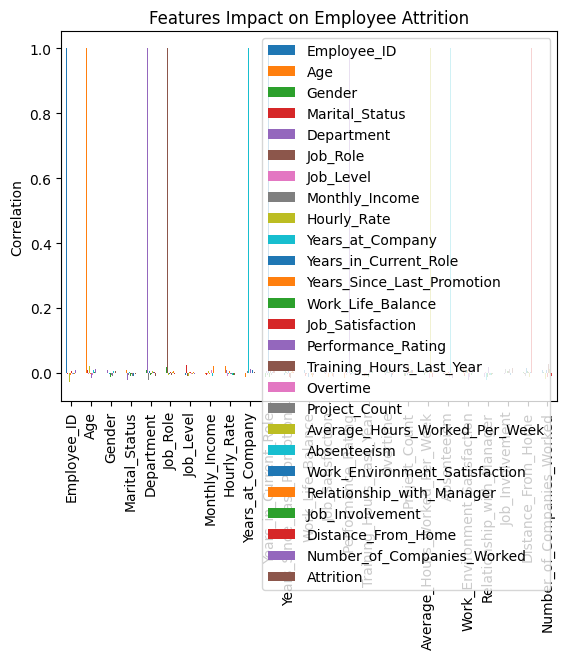

In [72]:
plt.figure(figsize=(10,6))

correlation.drop('Attrition').plot(kind='bar')

plt.title("Features Impact on Employee Attrition")
plt.ylabel("Correlation")

plt.show()

Text(0, 0.5, 'Number of Employees')

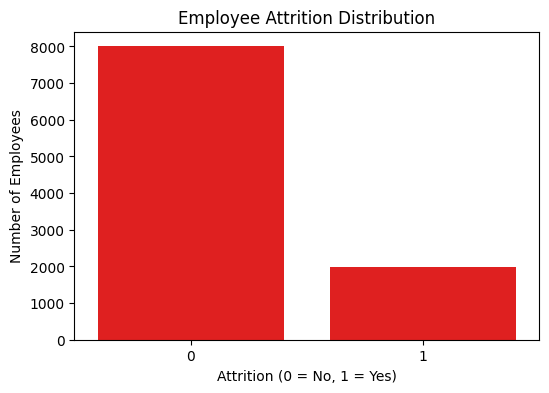

In [73]:
##Attrition Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Attrition', data=df,color='red')

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0 = No, 1 = Yes)")
plt.ylabel("Number of Employees")


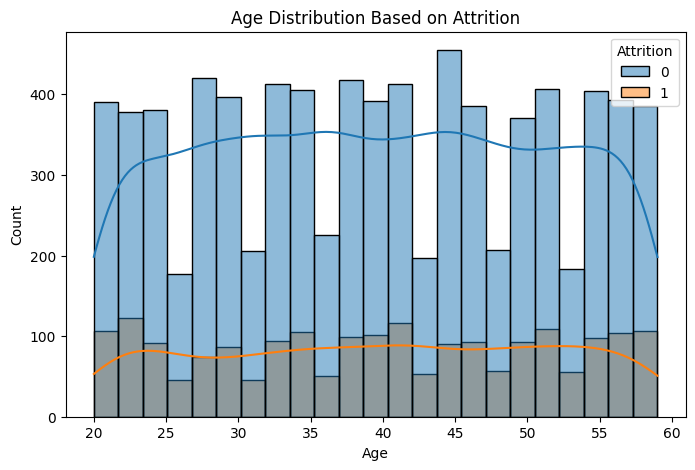

In [74]:
##Age Distribution by Attrition
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    kde=True,
    color='green'
)

plt.title("Age Distribution Based on Attrition")

plt.show()

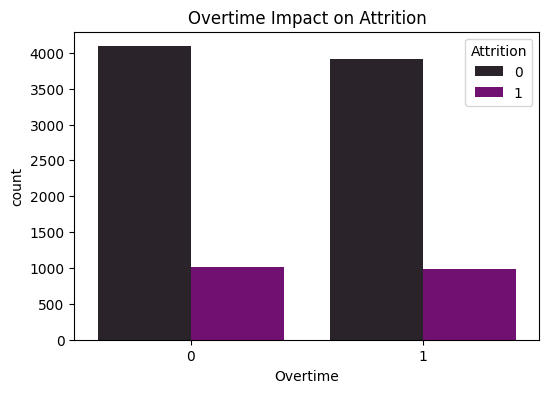

In [34]:
##OVERTIME IMPACT ON ATTRITION
plt.figure(figsize=(6,4))
sns.countplot(x='Overtime', hue='Attrition', data=df,color='purple')
plt.title('Overtime Impact on Attrition')
plt.show()

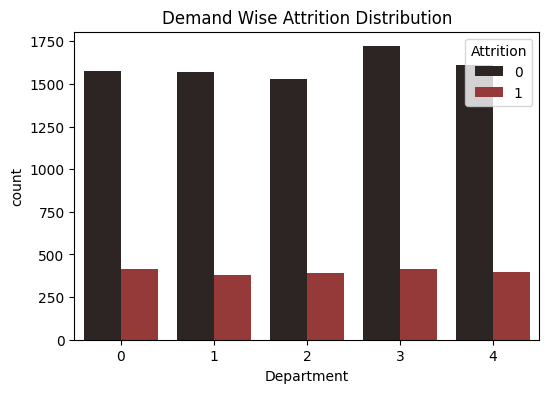

In [39]:
##demand wise Attrition Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Department',hue='Attrition',data=df,color='brown')
plt.title('Demand Wise Attrition Distribution')
plt.show()

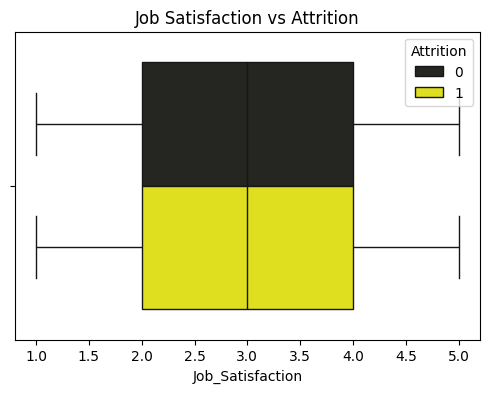

In [40]:
## job Satisfaction vs Attrition
plt.figure(figsize=(6,4))
sns.boxplot(x='Job_Satisfaction',hue='Attrition',data=df,color='yellow')
plt.title('Job Satisfaction vs Attrition')
plt.show()


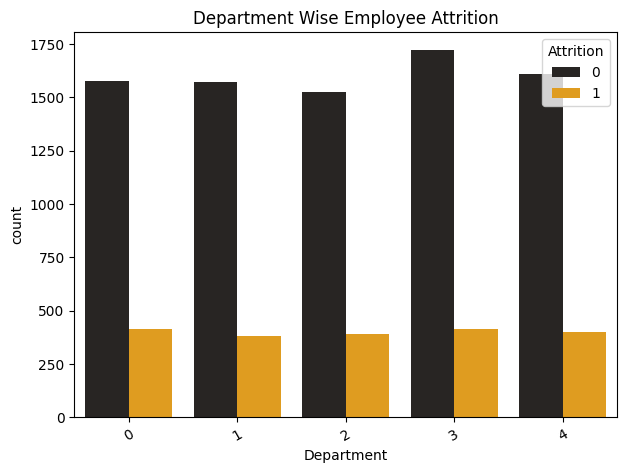

In [47]:
##Years At Company vs Attrition
plt.figure(figsize=(7,5))

sns.countplot(
    x='Department',
    hue='Attrition',
    data=df,
    color='orange'
)

plt.title("Department Wise Employee Attrition")

plt.xticks(rotation=30)

plt.show()

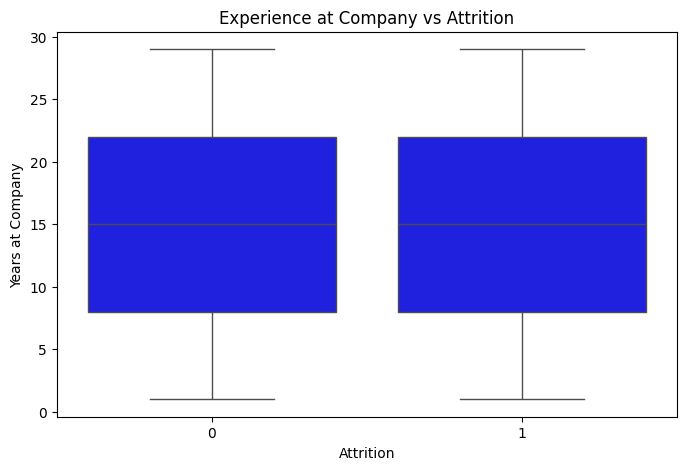

In [52]:
##Years At Company vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Years_at_Company',
    data=df,
    color='blue'
)

plt.title("Experience at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

In [95]:
print(df.dtypes)

Employee_ID                      int64
Age                              int64
Gender                             str
Marital_Status                     str
Department                         str
Job_Role                           str
Job_Level                        int64
Monthly_Income                   int64
Hourly_Rate                      int64
Years_at_Company                 int64
Years_in_Current_Role            int64
Years_Since_Last_Promotion       int64
Work_Life_Balance                int64
Job_Satisfaction                 int64
Performance_Rating               int64
Training_Hours_Last_Year         int64
Overtime                           str
Project_Count                    int64
Average_Hours_Worked_Per_Week    int64
Absenteeism                      int64
Work_Environment_Satisfaction    int64
Relationship_with_Manager        int64
Job_Involvement                  int64
Distance_From_Home               int64
Number_of_Companies_Worked       int64
Attrition                

In [98]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [99]:
##Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [101]:
##Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [103]:
# Parameter Grid
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Model
grid_lr.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [104]:
###Best Parameters
print("Best Parameters:")
print(grid_lr.best_params_)
##Best Accuracy
print("Best CV Accuracy:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 0.01, 'solver': 'liblinear'}
Best CV Accuracy:
0.8002500000000001


In [105]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_scaled)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_best_lr))

Test Accuracy: 0.8005


In [106]:
dt_params = {

    'criterion': ['gini', 'entropy'],

    'max_depth': [5, 10, 15, 20, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    param_grid=dt_params,

    cv=5,

    scoring='accuracy',

    n_jobs=-1

)

grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [107]:
#Best Parameters
print(grid_dt.best_params_)
##Best CV Score
print(grid_dt.best_score_)
##Prediction
best_dt = grid_dt.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_best_dt))

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.79675
Accuracy: 0.799
